In [1]:
# Notebook 2 — CICIDS2017 Cross-Dataset Evaluation
# Requires gnn_model_*.pt from Notebook 1


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import joblib

from torch_geometric.nn import GCNConv, GATConv, SAGEConv, RGCNConv, GINConv, ChebConv
from torch_geometric.data import Data
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.preprocessing import StandardScaler


class GNNModel(torch.nn.Module):
    """
    6 GNN architectures in one class.
    self.model_type MUST be stored — forward() branches on it for RGCN.
    # MAINTENANCE: this class is duplicated in all 3 notebooks.
    # If you change it here, update 01_NSLKDDCoreTraining_FINAL.ipynb
    # and 03_UNSW_Evaluation_FINAL.ipynb to match.
    """
    def __init__(self, input_dim, hidden_dim, output_dim, model_type='GCN'):
        super().__init__()
        self.model_type = model_type

        if model_type == 'GCN':
            self.conv1 = GCNConv(input_dim, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, output_dim)
        elif model_type == 'GAT':
            self.conv1 = GATConv(input_dim, hidden_dim, heads=4, concat=True)
            self.conv2 = GATConv(hidden_dim * 4, output_dim, heads=1, concat=False)
        elif model_type == 'SAGE':
            self.conv1 = SAGEConv(input_dim, hidden_dim)
            self.conv2 = SAGEConv(hidden_dim, output_dim)
        elif model_type == 'RGCN':
            self.conv1 = RGCNConv(input_dim, hidden_dim, num_relations=1)
            self.conv2 = RGCNConv(hidden_dim, output_dim, num_relations=1)
        elif model_type == 'GIN':
            mlp1 = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                  nn.Linear(hidden_dim, hidden_dim))
            mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Linear(hidden_dim, output_dim))
            self.conv1 = GINConv(mlp1, train_eps=True)
            self.conv2 = GINConv(mlp2, train_eps=True)
        elif model_type == 'CHEB':
            self.conv1 = ChebConv(input_dim, hidden_dim, K=3)
            self.conv2 = ChebConv(hidden_dim, output_dim, K=3)
        else:
            raise ValueError(f'Unknown model_type: {model_type}')

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        if self.model_type == 'RGCN':
            et = torch.zeros(edge_index.size(1), dtype=torch.long)
            x = F.relu(self.conv1(x, edge_index, et))
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index, et)
        else:
            x = F.relu(self.conv1(x, edge_index))
            x = F.dropout(x, p=0.5, training=self.training)
            x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

@torch.no_grad()
def evaluate(model, data, find_best_threshold=False):
    """
    Notebooks 2 & 3 — scores all nodes.

    find_best_threshold=True: sweep thresholds 0.05-0.95 and pick the one
    that maximises F1.  Useful for cross-dataset eval where train/test class
    distributions differ.  ROC-AUC is always threshold-independent.
    """
    model.eval()
    logits = model(data)
    y_true = data.y
    probs  = logits.exp()[:, 1]
    yt = y_true.cpu().numpy()
    pr = probs.cpu().numpy()

    # Orient probabilities: if raw AUC < 0.5 the model's confidence is inverted
    raw_auc = roc_auc_score(yt, pr)
    auc_flipped = raw_auc < 0.5
    if auc_flipped:
        pr = 1.0 - pr
    auc = max(raw_auc, 1 - raw_auc)

    if find_best_threshold:
        best_f1, best_thresh, best_preds = 0.0, 0.5, (pr >= 0.5).astype(int)
        for t in np.arange(0.05, 0.96, 0.01):
            cand = (pr >= t).astype(int)
            f = f1_score(yt, cand, zero_division=0)
            if f > best_f1:
                best_f1, best_thresh, best_preds = f, t, cand
        yp = best_preds
    else:
        yp = (pr >= 0.5).astype(int)

    return dict(accuracy=accuracy_score(yt, yp),
                f1=f1_score(yt, yp, zero_division=0),
                precision=precision_score(yt, yp, zero_division=0),
                recall=recall_score(yt, yp, zero_division=0),
                roc_auc=auc)

def make_graph(X_vals, y_vals, split=False):
    """
    Build a bidirectional sequential graph.
    Bidirectional edges (i→i+1 AND i+1→i) give GCN a 2-node neighbourhood
    instead of 1-node, which is critical for GCN convergence on chain graphs.
    """
    N = len(y_vals)
    fwd = [np.arange(0, N-1), np.arange(1, N)]
    bwd = [np.arange(1, N),   np.arange(0, N-1)] # reversed direction
    ei  = torch.tensor(np.concatenate([fwd, bwd], axis=1), dtype=torch.long)

    g = Data(x=torch.tensor(X_vals, dtype=torch.float),
             edge_index=ei,
             y=torch.tensor(y_vals, dtype=torch.long))
    if split:
        from sklearn.model_selection import train_test_split
        tr, te = train_test_split(np.arange(N), test_size=0.2,
                                  stratify=y_vals, random_state=42)
        tm = torch.zeros(N, dtype=torch.bool); tm[tr] = True
        vm = torch.zeros(N, dtype=torch.bool); vm[te] = True
        g.train_mask = tm; g.test_mask = vm
    return g
COMMON_FEATURES = [
    'duration', # connection duration
    'src_bytes', # bytes source→dest
    'dst_bytes', # bytes dest→source
    'count', # same-host connections in window
    'srv_count', # same-service connections in window
    'serror_rate', # SYN-error rate  (0-1)
    'rerror_rate', # REJ-error rate  (0-1)
    'same_srv_rate', # same-service rate (0-1)
]
print("Setup complete.")


Setup complete.


In [ ]:
# Load & Preprocess CICIDS2017 
df_cic = pd.read_csv('Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')
df_cic.columns = df_cic.columns.str.strip()

# Map to COMMON_FEATURES 
# duration: Flow Duration (microseconds → divide by 1e6 → seconds)
df_cic['duration'] = df_cic['Flow Duration'] / 1e6

# src_bytes / dst_bytes: use BYTE counts (not packet counts)
if 'Total Length of Fwd Packets' in df_cic.columns:
    df_cic['src_bytes'] = df_cic['Total Length of Fwd Packets']
    df_cic['dst_bytes'] = df_cic['Total Length of Bwd Packets']
else:
    # Older CICIDS column names
    df_cic['src_bytes'] = df_cic.get('Fwd Header Length', df_cic['Total Fwd Packets'])
    df_cic['dst_bytes'] = df_cic.get('Bwd Header Length', df_cic['Total Backward Packets'])

# count / srv_count: packet rate features as connection-count proxies
tot = (df_cic['Total Fwd Packets'] + df_cic['Total Backward Packets']).replace(0,1)
df_cic['count']     = df_cic['Total Fwd Packets']
df_cic['srv_count'] = df_cic['Total Backward Packets']

# serror_rate / rerror_rate: SYN and RST flag rates
df_cic['serror_rate'] = (df_cic['SYN Flag Count'] / tot).clip(0,1) if 'SYN Flag Count' in df_cic.columns else 0.0
df_cic['rerror_rate'] = (df_cic['RST Flag Count'] / tot).clip(0,1) if 'RST Flag Count' in df_cic.columns else 0.0

# same_srv_rate: normalised mean packet length as service-consistency proxy
if 'Avg Fwd Segment Size' in df_cic.columns:
    s = df_cic['Avg Fwd Segment Size'].replace([np.inf,-np.inf], np.nan).fillna(0)
elif 'Fwd Packet Length Mean' in df_cic.columns:
    s = df_cic['Fwd Packet Length Mean'].replace([np.inf,-np.inf], np.nan).fillna(0)
else:
    s = pd.Series(np.zeros(len(df_cic)))
mx = s.quantile(0.99)
df_cic['same_srv_rate'] = (s.clip(0, mx) / mx).fillna(0) if mx > 0 else 0.0

# Labels
df_cic['label_binary'] = (df_cic['Label'] != 'BENIGN').astype(int)
y_cic = df_cic['label_binary'].values

X_cic = df_cic[COMMON_FEATURES].fillna(0).replace([np.inf,-np.inf], 0).values

#  FIT a fresh scaler on CICIDS data 
# Rationale: cross-dataset evaluation tests whether learned graph STRUCTURE
# (weights, attention, neighbourhood aggregation) transfers across datasets —
# not whether raw feature scales transfer.  Each dataset is independently
# normalised to zero-mean/unit-variance, which is standard practice in
# cross-dataset IDS papers (e.g. E-GraphSAGE, CSE-IDS).
cic_scaler = StandardScaler()
X_cic_scaled = cic_scaler.fit_transform(X_cic)

print(f"Rows: {len(df_cic)} | Labels: {dict(pd.Series(y_cic).value_counts())}")
print(f"Attack rate: {y_cic.mean():.2%}")
print(f"NaN in X: {np.isnan(X_cic_scaled).sum()}")


Rows: 286467 | Labels: {1: np.int64(158930), 0: np.int64(127537)}
Attack rate: 55.48%
NaN in X: 0


In [4]:
cic_graph = make_graph(X_cic_scaled, y_cic, split=False)
print(f"Graph: {cic_graph.num_nodes} nodes, {cic_graph.num_edges} edges")


Graph: 286467 nodes, 572932 edges


In [5]:
model_types = ['GCN', 'GAT', 'SAGE', 'RGCN', 'GIN', 'CHEB']
cic_results = {}

for m_type in model_types:
    model = GNNModel(len(COMMON_FEATURES), 64, 2, m_type)
    pt = f'gnn_model_{m_type.lower()}.pt'
    try:
        model.load_state_dict(torch.load(pt, map_location='cpu', weights_only=True))
        cic_results[m_type] = evaluate(model, cic_graph)
        r = cic_results[m_type]
        with torch.no_grad():
            n_pred = model(cic_graph).argmax(dim=1).sum().item()
        print(f"{m_type:<6} acc={r['accuracy']:.3f} f1={r['f1']:.3f} "
              f"prec={r['precision']:.3f} rec={r['recall']:.3f} auc={r['roc_auc']:.3f} "
              f"| predicted_attack={n_pred}/{len(y_cic)}")
    except FileNotFoundError:
        print(f"{m_type}: {pt} not found — run Notebook 1 first.")
    except Exception as e:
        print(f"{m_type}: ERROR — {e}")


GCN    acc=0.373 f1=0.002 prec=0.009 rec=0.001 auc=0.827 | predicted_attack=21033/286467
GAT    acc=0.665 f1=0.768 prec=0.623 rec=1.000 auc=0.914 | predicted_attack=254964/286467
SAGE   acc=0.867 f1=0.893 prec=0.808 rec=0.997 auc=0.866 | predicted_attack=196077/286467
RGCN   acc=0.915 f1=0.929 prec=0.869 rec=0.997 auc=0.842 | predicted_attack=182274/286467
GIN    acc=0.896 f1=0.913 prec=0.851 rec=0.985 auc=0.870 | predicted_attack=183868/286467
CHEB   acc=0.897 f1=0.915 prec=0.844 rec=0.998 auc=0.859 | predicted_attack=187976/286467



CICIDS2017 Cross-Dataset Results (trained on NSL-KDD):
      accuracy      f1  precision  recall  roc_auc
GCN     0.3731  0.0021     0.0090  0.0012   0.8273
GAT     0.6646  0.7679     0.6233  0.9999   0.9136
SAGE    0.8674  0.8930     0.8084  0.9974   0.8664
RGCN    0.9153  0.9289     0.8694  0.9971   0.8421
GIN     0.8962  0.9133     0.8513  0.9849   0.8700
CHEB    0.8967  0.9147     0.8440  0.9983   0.8589


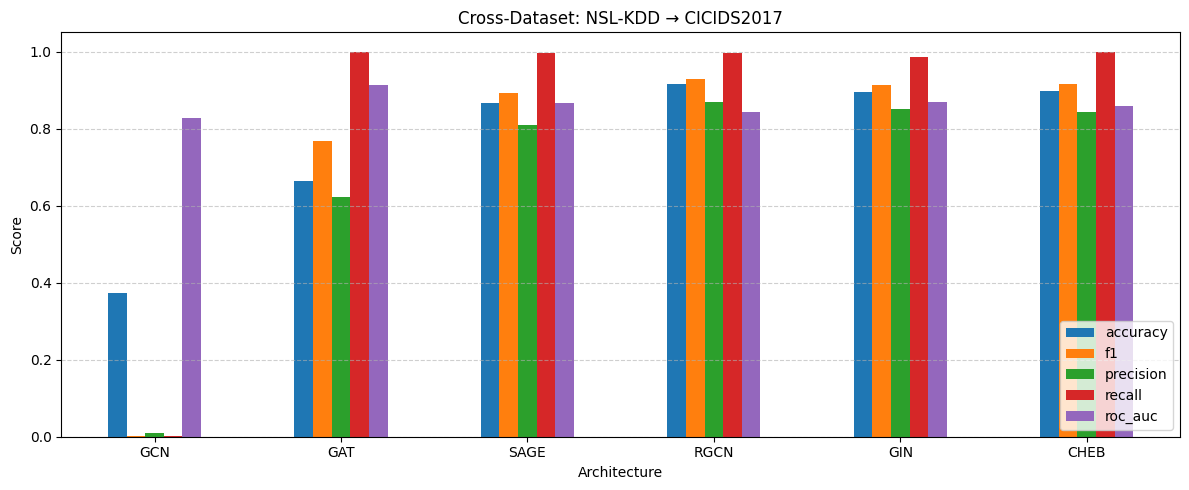

In [6]:
df_cic_res = pd.DataFrame(cic_results).T.round(4)
print("\nCICIDS2017 Cross-Dataset Results (trained on NSL-KDD):")
print(df_cic_res.to_string())

fig, ax = plt.subplots(figsize=(12,5))
df_cic_res.plot(kind='bar', ax=ax)
ax.set_title('Cross-Dataset: NSL-KDD → CICIDS2017')
ax.set_ylabel('Score'); ax.set_xlabel('Architecture')
ax.set_ylim(0, 1.05); ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right'); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()
